In [18]:
import pandas as pd


df = pd.read_csv("/app/data/yash-m2m/Data/full_data_table.csv", index_col=0)
df.head()

,chosen_exam,array,gender,age_diag,grade,cancer_history,ajcc_path_tumor_pt,ajcc_path_nodes_pn,ajcc_clin_metastasis_cm,ajcc_path_metastasis_pm,...,Func_MAX,Func_HIST1H2BM,Func_EME2,Func_CELA1,Func_FRG2B,Func_GPRC6A,TMB_Count,TMB_Value,class_labels,class_labels_MYC_V2_median
TCGA-A3-3311,TCGA-A3-3311-01A-01-BS1.npz,[[0.09420455 0.00782806 0.01335143 ... 0.00516...,1,4.0,2,NaN,1,0,-1,1,...,WT,WT,WT,WT,WT,WT,57,0.000002,NON_ccA/B,above_median
TCGA-A3-3316,TCGA-A3-3316-11A-01-BS1.npz,[[0.08240734 0.00747561 0.01144183 ... 0.00945...,1,4.0,3,NaN,4,0,-1,1,...,WT,WT,WT,WT,WT,WT,43,0.000002,ccB_only,below_median
TCGA-A3-3317,TCGA-A3-3317-01A-02-BS2.npz,[[0.08040426 0.01684249 0.0070834 ... 0.00849...,1,5.0,2,NaN,4,1,-1,1,...,WT,WT,WT,WT,WT,WT,61,0.000002,ccB_only,above_median
TCGA-A3-3320,TCGA-A3-3320-01A-01-BS1.npz,[[0.09117609 0.00739556 0.01012404 ... 0.00628...,0,4.0,1,NaN,3,0,-1,1,...,WT,WT,WT,WT,WT,WT,75,0.000003,ccA_only,below_median
TCGA-A3-3322,TCGA-A3-3322-11A-01-TS1.npz,[[0.07906659 0.01137321 0.00670323 ... 0.00638...,1,4.0,2,NaN,2,0,-1,1,...,WT,WT,WT,WT,WT,WT,48,0.000002,ccA_only,below_median


# Gene selection

In [19]:
# Only TMB_Count (not TMB_Value) — mirrors R: subset(raw_data, select = -TMB_Value)
gene_data_cols = [c for c in df.columns if c.startswith("Func_") or c == "TMB_Count"]

target_col = "class_labels_MYC_V2_median"
allowed_binary_labels = ["below_median", "above_median"]

# Ensure binary MYC label exists in df (load from external table if needed)
if target_col not in df.columns:
    myc_labels = pd.read_csv(
        "/app/data/yash-m2m/Data/Gene expressions/tcga_DNA_MYC.csv",
        index_col="PATIENT_ID",
    )[[target_col]]
    df = df.join(myc_labels, how="left")

gene_data = df[gene_data_cols + [target_col]].copy()

unexpected = set(gene_data[target_col].dropna().astype(str).unique()) - set(allowed_binary_labels)
if unexpected:
    raise ValueError(f"Unexpected {target_col} values: {unexpected}")

print("gene feature columns:", len(gene_data_cols))
print(gene_data_cols)
print(f"\nTarget ({target_col}) distribution:")
print(gene_data[target_col].value_counts(dropna=False))

gene_data.head()


gene feature columns: 165
['Func_MSR1', 'Func_MUC4', 'Func_PTEN', 'Func_VHL', 'Func_CERCAM', 'Func_PBRM1', 'Func_PLEKHA2', 'Func_SETD2', 'Func_CD300E', 'Func_ANKRD36', 'Func_BAP1', 'Func_CHIT1', 'Func_ZNF304', 'Func_ARID1A', 'Func_GRIN3B', 'Func_NREP', 'Func_SYT15', 'Func_TXLNA', 'Func_ARHGEF25', 'Func_CCNB2', 'Func_SERPINB13', 'Func_PCK1', 'Func_FMN2', 'Func_LCN1', 'Func_MTOR', 'Func_ANKRD12', 'Func_OR4M2', 'Func_PIK3CA', 'Func_POC1B', 'Func_YLPM1', 'Func_AGAP6', 'Func_COL6A6', 'Func_KMT2C', 'Func_L1TD1', 'Func_TFDP2', 'Func_DIXDC1', 'Func_MAK16', 'Func_CPLX2', 'Func_IPP', 'Func_KRTAP4-9', 'Func_COL5A3', 'Func_PDE4C', 'Func_GATA2', 'Func_KDM5C', 'Func_KRTAP5-5', 'Func_MCPH1', 'Func_PABPC3', 'Func_RALGAPA1', 'Func_MSLNL', 'Func_PABPC1', 'Func_OR2T35', 'Func_RHEB', 'Func_DPPA2', 'Func_NEFH', 'Func_BTNL3', 'Func_C1orf52', 'Func_HLA-DRB5', 'Func_CRIPAK', 'Func_OVGP1', 'Func_TMEM255B', 'Func_MAP2K3', 'Func_POTED', 'Func_TRIP12', 'Func_ATM', 'Func_GINS3', 'Func_DHX37', 'Func_MAP7D1', 'Func_

,Func_MSR1,Func_MUC4,Func_PTEN,Func_VHL,Func_CERCAM,Func_PBRM1,Func_PLEKHA2,Func_SETD2,Func_CD300E,Func_ANKRD36,...,Func_FAM209A,Func_VCX2,Func_MAX,Func_HIST1H2BM,Func_EME2,Func_CELA1,Func_FRG2B,Func_GPRC6A,TMB_Count,class_labels_MYC_V2_median
TCGA-A3-3311,WT,WT,WT,WT,WT,WT,LOF,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,57,above_median
TCGA-A3-3316,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,43,below_median
TCGA-A3-3317,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,61,above_median
TCGA-A3-3320,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,75,below_median
TCGA-A3-3322,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,48,below_median


## All gene data (binary target: MYC median class)

In [28]:

# ML model — replicates 02_ml_model.R + 02_ml_model_v2.R (binary target)
# Key parity changes vs old version:
#   - Logistic: C=1e10 (unregularized, mirrors glm(family=binomial))
#   - RF: n_estimators=500, max_features=floor(sqrt(p)) (mirrors ranger defaults)
#   - Per-fold zero-variance filter on Func_ columns (mirrors v2)
#   - Pooled OOF AUC instead of mean-fold AUC (mirrors pROC roc() on accumulated preds)
import math
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

func_cols = [c for c in gene_data_cols if c.startswith("Func_")]

gene_data_mod = gene_data.copy()
for c in func_cols:
    gene_data_mod[c] = gene_data_mod[c].map({"WT": 0, "LOF": 1})
gene_data_mod = gene_data_mod.dropna()

X = gene_data_mod[gene_data_cols]
y = gene_data_mod[target_col].astype(str)
positive_label = "above_median"
print("class distribution:", y.value_counts(normalize=True).to_dict())

# Stratified 80/20 split — mirrors initial_split(strata = class_labels_MYC_V2_median)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

# 10-fold stratified CV — mirrors vfold_cv(v=10, strata=...)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

cv_logit_acc, cv_logit_f1 = [], []
cv_rf_acc,    cv_rf_f1    = [], []

# Pooled OOF containers — mirrors pROC roc() on all fold predictions at once
all_logit_probs, all_logit_obs = [], []
all_rf_probs,    all_rf_obs    = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Per-fold zero-variance filter on Func_ columns (mirrors 02_ml_model_v2.R)
    nv_func = [c for c in func_cols if X_tr[c].nunique() > 1]
    fold_cols = ["TMB_Count"] + nv_func
    X_tr_fold  = X_tr[fold_cols]
    X_val_fold = X_val[fold_cols]

    # Logistic — unregularized (C=1e10 ≈ no penalty), mirrors glm(family=binomial)
    logit = LogisticRegression(C=1e10, max_iter=1000, random_state=123, solver='lbfgs')
    logit.fit(X_tr_fold, y_tr)
    logit_preds = logit.predict(X_val_fold)
    logit_pos_idx = list(logit.classes_).index(positive_label)
    logit_probs = logit.predict_proba(X_val_fold)[:, logit_pos_idx]

    cv_logit_acc.append(accuracy_score(y_val, logit_preds))
    cv_logit_f1.append(f1_score(y_val, logit_preds, pos_label=positive_label, zero_division=0))
    all_logit_probs.extend(logit_probs.tolist())
    all_logit_obs.extend(y_val.tolist())

    # RF — n_estimators=500, mtry=floor(sqrt(p)) (mirrors ranger defaults)
    n_fold_features = len(fold_cols)
    rf = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(n_fold_features))),
        random_state=123
    )
    rf.fit(X_tr_fold, y_tr)
    rf_preds = rf.predict(X_val_fold)
    rf_pos_idx = list(rf.classes_).index(positive_label)
    rf_probs = rf.predict_proba(X_val_fold)[:, rf_pos_idx]

    cv_rf_acc.append(accuracy_score(y_val, rf_preds))
    cv_rf_f1.append(f1_score(y_val, rf_preds, pos_label=positive_label, zero_division=0))
    all_rf_probs.extend(rf_probs.tolist())
    all_rf_obs.extend(y_val.tolist())

# Pooled OOF AUC (mirrors pROC roc() on all accumulated predictions)
logit_auc_pooled = roc_auc_score(
    [1 if o == positive_label else 0 for o in all_logit_obs], all_logit_probs
)
rf_auc_pooled = roc_auc_score(
    [1 if o == positive_label else 0 for o in all_rf_obs], all_rf_probs
)

print(f"Logit CV acc  {np.mean(cv_logit_acc):.3f}")
print(f"Logit CV F1   {np.mean(cv_logit_f1):.3f}")
print(f"Logit OOF AUC {logit_auc_pooled:.3f}")
print(f"RF CV acc     {np.mean(cv_rf_acc):.3f}")
print(f"RF CV F1      {np.mean(cv_rf_f1):.3f}")
print(f"RF OOF AUC    {rf_auc_pooled:.3f}")

# Final train→test evaluation
final_logit = LogisticRegression(C=1e10, max_iter=1000, random_state=123, solver='lbfgs')
final_logit.fit(X_train, y_train)
test_logit_preds = final_logit.predict(X_test)
test_logit_probs = final_logit.predict_proba(X_test)[:, list(final_logit.classes_).index(positive_label)]
print(f"\nTest Logit acc {accuracy_score(y_test, test_logit_preds):.3f}")
print(f"Test Logit F1  {f1_score(y_test, test_logit_preds, pos_label=positive_label, zero_division=0):.3f}")
print(f"Test Logit AUC {roc_auc_score((y_test == positive_label).astype(int), test_logit_probs):.3f}")

final_rf = RandomForestClassifier(
    n_estimators=500,
    max_features=max(1, math.floor(math.sqrt(len(gene_data_cols)))),
    random_state=123
)
final_rf.fit(X_train, y_train)
test_rf_preds = final_rf.predict(X_test)
test_rf_probs = final_rf.predict_proba(X_test)[:, list(final_rf.classes_).index(positive_label)]
print(f"Test RF acc    {accuracy_score(y_test, test_rf_preds):.3f}")
print(f"Test RF F1     {f1_score(y_test, test_rf_preds, pos_label=positive_label, zero_division=0):.3f}")
print(f"Test RF AUC    {roc_auc_score((y_test == positive_label).astype(int), test_rf_probs):.3f}")


class distribution: {'above_median': 0.5077399380804953, 'below_median': 0.49226006191950467}
Logit CV acc  0.554
Logit CV F1   0.532
Logit OOF AUC 0.540
RF CV acc     0.501
RF CV F1      0.513
RF OOF AUC    0.548

Test Logit acc 0.431
Test Logit F1  0.413
Test Logit AUC 0.446
Test RF acc    0.538
Test RF F1     0.559
Test RF AUC    0.537


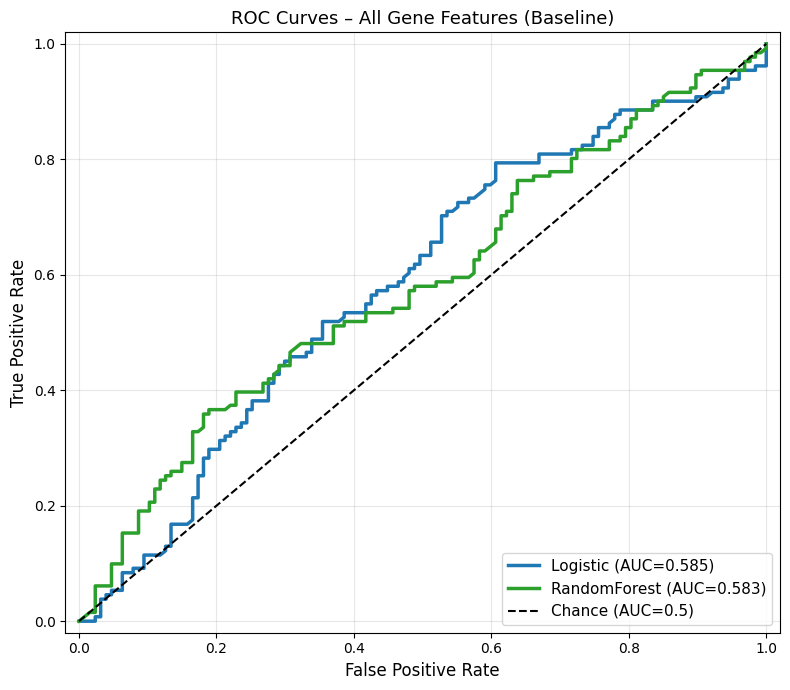

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for all-genes model (pooled OOF) — both models on same plot
fig, ax = plt.subplots(figsize=(8, 7))

# Logistic ROC
fpr_logit, tpr_logit, _ = roc_curve(
    [1 if o == positive_label else 0 for o in all_logit_obs],
    all_logit_probs
)
auc_logit = auc(fpr_logit, tpr_logit)
ax.plot(fpr_logit, tpr_logit, color='tab:blue', lw=2.5, label=f'Logistic (AUC={auc_logit:.3f})')

# RF ROC
fpr_rf, tpr_rf, _ = roc_curve(
    [1 if o == positive_label else 0 for o in all_rf_obs],
    all_rf_probs
)
auc_rf = auc(fpr_rf, tpr_rf)
ax.plot(fpr_rf, tpr_rf, color='tab:green', lw=2.5, label=f'RandomForest (AUC={auc_rf:.3f})')

# Chance line
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC=0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves – All Gene Features (Baseline)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()


## Subset of genes from R scripts (binary target)

In [ ]:

# Model on 21 R-selected features — replicates 04_fs_results.R (binary target)
# Same R-parity settings: unregularized logistic, RF n_estimators=500 mtry=floor(sqrt(p)),
# pooled OOF AUC
import math
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

selected_features = [
    "TMB_Count",
    "Func_MEGF6",
    "Func_ATG7",
    "Func_POLDIP2",
    "Func_COL5A3",
    "Func_MSLNL",
    "Func_SERPINB13",
    "Func_ST8SIA4",
    "Func_OR2T35",
    "Func_CHIT1",
    "Func_CASP5",
    "Func_TAS2R50",
    "Func_HOXC8",
    "Func_ARHGAP5",
    "Func_ANKRD36",
    "Func_SYT15",
    "Func_FAM209A",
    "Func_VCX3B",
    "Func_PTPRK",
    "Func_GATA2",
    "Func_CACYBP",
]

fs_data = df[selected_features + [target_col]].copy()
for c in selected_features:
    if c.startswith("Func_"):
        fs_data[c] = fs_data[c].map({"WT": 0, "LOF": 1})
fs_data = fs_data.dropna()

X_fs = fs_data[selected_features]
y_fs = fs_data[target_col].astype(str)
positive_label = "above_median"

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, stratify=y_fs, random_state=123
)

skf_fs = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_logit_acc_fs, cv_logit_f1_fs = [], []
cv_rf_acc_fs,    cv_rf_f1_fs    = [], []
all_logit_probs_fs, all_logit_obs_fs = [], []
all_rf_probs_fs,    all_rf_obs_fs    = [], []

for train_idx, val_idx in skf_fs.split(X_train_fs, y_train_fs):
    X_tr, X_val = X_train_fs.iloc[train_idx], X_train_fs.iloc[val_idx]
    y_tr, y_val = y_train_fs.iloc[train_idx], y_train_fs.iloc[val_idx]

    logit_fs = LogisticRegression(C=1e10, max_iter=1000, random_state=123, solver='lbfgs')
    logit_fs.fit(X_tr, y_tr)
    logit_preds_fs = logit_fs.predict(X_val)
    logit_probs_fs = logit_fs.predict_proba(X_val)[:, list(logit_fs.classes_).index(positive_label)]
    cv_logit_acc_fs.append(accuracy_score(y_val, logit_preds_fs))
    cv_logit_f1_fs.append(f1_score(y_val, logit_preds_fs, pos_label=positive_label, zero_division=0))
    all_logit_probs_fs.extend(logit_probs_fs.tolist())
    all_logit_obs_fs.extend(y_val.tolist())

    rf_fs = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(len(selected_features)))),
        random_state=123
    )
    rf_fs.fit(X_tr, y_tr)
    rf_preds_fs = rf_fs.predict(X_val)
    rf_probs_fs = rf_fs.predict_proba(X_val)[:, list(rf_fs.classes_).index(positive_label)]
    cv_rf_acc_fs.append(accuracy_score(y_val, rf_preds_fs))
    cv_rf_f1_fs.append(f1_score(y_val, rf_preds_fs, pos_label=positive_label, zero_division=0))
    all_rf_probs_fs.extend(rf_probs_fs.tolist())
    all_rf_obs_fs.extend(y_val.tolist())

logit_auc_pooled_fs = roc_auc_score(
    [1 if o == positive_label else 0 for o in all_logit_obs_fs], all_logit_probs_fs
)
rf_auc_pooled_fs = roc_auc_score(
    [1 if o == positive_label else 0 for o in all_rf_obs_fs], all_rf_probs_fs
)

print(f"Selected-features Logit CV acc  {np.mean(cv_logit_acc_fs):.3f}")
print(f"Selected-features Logit CV F1   {np.mean(cv_logit_f1_fs):.3f}")
print(f"Selected-features Logit OOF AUC {logit_auc_pooled_fs:.3f}")
print(f"Selected-features RF CV acc     {np.mean(cv_rf_acc_fs):.3f}")
print(f"Selected-features RF CV F1      {np.mean(cv_rf_f1_fs):.3f}")
print(f"Selected-features RF OOF AUC    {rf_auc_pooled_fs:.3f}")

final_logit_fs = LogisticRegression(C=1e10, max_iter=1000, random_state=123, solver='lbfgs')
final_logit_fs.fit(X_train_fs, y_train_fs)
test_logit_preds_fs = final_logit_fs.predict(X_test_fs)
test_logit_probs_fs = final_logit_fs.predict_proba(X_test_fs)[:, list(final_logit_fs.classes_).index(positive_label)]
print(f"\nTest Logit acc {accuracy_score(y_test_fs, test_logit_preds_fs):.3f}")
print(f"Test Logit F1  {f1_score(y_test_fs, test_logit_preds_fs, pos_label=positive_label, zero_division=0):.3f}")
print(f"Test Logit AUC {roc_auc_score((y_test_fs == positive_label).astype(int), test_logit_probs_fs):.3f}")

final_rf_fs = RandomForestClassifier(
    n_estimators=500,
    max_features=max(1, math.floor(math.sqrt(len(selected_features)))),
    random_state=123
)
final_rf_fs.fit(X_train_fs, y_train_fs)
test_rf_preds_fs = final_rf_fs.predict(X_test_fs)
test_rf_probs_fs = final_rf_fs.predict_proba(X_test_fs)[:, list(final_rf_fs.classes_).index(positive_label)]
print(f"Test RF acc    {accuracy_score(y_test_fs, test_rf_preds_fs):.3f}")
print(f"Test RF F1     {f1_score(y_test_fs, test_rf_preds_fs, pos_label=positive_label, zero_division=0):.3f}")
print(f"Test RF AUC    {roc_auc_score((y_test_fs == positive_label).astype(int), test_rf_probs_fs):.3f}")

Selected-features Logit CV acc  0.620
Selected-features Logit CV F1   0.611
Selected-features Logit OOF AUC 0.666
Selected-features RF CV acc     0.558
Selected-features RF CV F1      0.528
Selected-features RF OOF AUC    0.581

Test Logit acc 0.446
Test Logit F1  0.419
Test Logit AUC 0.501
Test RF acc    0.538
Test RF F1     0.545
Test RF AUC    0.549


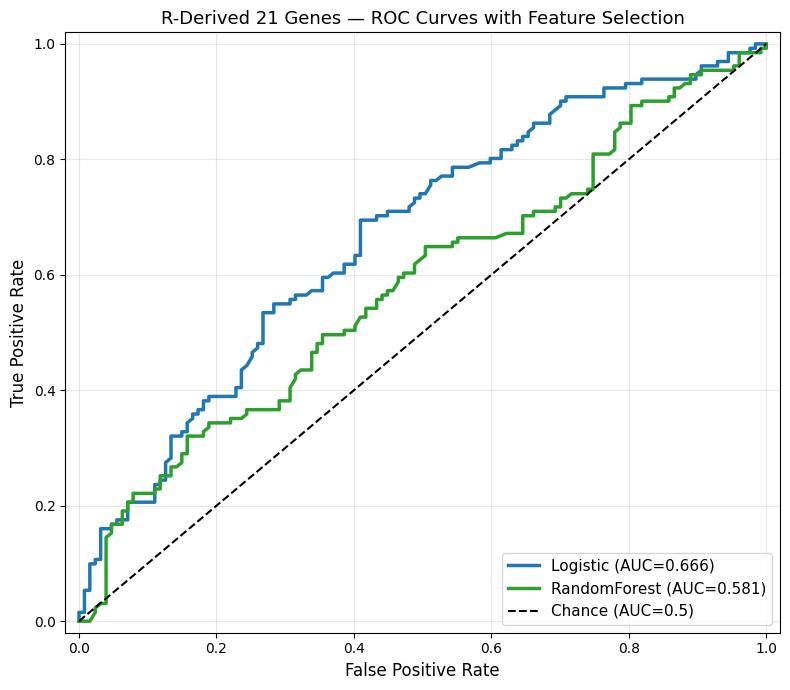

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for selected 21-gene model (pooled OOF) — both models on same plot
fig, ax = plt.subplots(figsize=(8, 7))

# Logistic ROC
fpr_logit_fs, tpr_logit_fs, _ = roc_curve(
    [1 if o == positive_label else 0 for o in all_logit_obs_fs],
    all_logit_probs_fs
)
auc_logit_fs = auc(fpr_logit_fs, tpr_logit_fs)
ax.plot(fpr_logit_fs, tpr_logit_fs, color='tab:blue', lw=2.5, label=f'Logistic (AUC={auc_logit_fs:.3f})')

# RF ROC
fpr_rf_fs, tpr_rf_fs, _ = roc_curve(
    [1 if o == positive_label else 0 for o in all_rf_obs_fs],
    all_rf_probs_fs
)
auc_rf_fs = auc(fpr_rf_fs, tpr_rf_fs)
ax.plot(fpr_rf_fs, tpr_rf_fs, color='tab:green', lw=2.5, label=f'RandomForest (AUC={auc_rf_fs:.3f})')

# Chance line
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC=0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('R-Derived 21 Genes - ROC Curves with Feature Selection', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()


## Feature selection using binary MYC labels

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
import numpy as np
import pandas as pd

# Leakage-safe setup: create one outer split and rank features using training data only
X_all = gene_data_mod[gene_data_cols]
y_all = gene_data_mod[target_col].astype(str)

X_outer_train, X_outer_test, y_outer_train, y_outer_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=123,
)

feature_count = min(50, X_outer_train.shape[1])


def _discretize_series(s: pd.Series, n_bins: int = 5) -> pd.Series:
    """Discretize a numeric/categorical feature into stable integer bins for MI."""
    s = s.copy()

    # Keep binary mutation columns as-is where possible
    if s.dropna().isin([0, 1]).all():
        return s.fillna(0).astype(int)

    # If numeric, quantile-bin; if not, factorize categories
    if pd.api.types.is_numeric_dtype(s):
        non_na = s.dropna()
        if non_na.nunique() <= 2:
            return s.fillna(non_na.median() if len(non_na) else 0).astype(float).round().astype(int)
        try:
            binned = pd.qcut(non_na, q=min(n_bins, non_na.nunique()), labels=False, duplicates="drop")
            out = pd.Series(index=s.index, dtype=float)
            out.loc[non_na.index] = binned.astype(float)
            out = out.fillna(out.median() if out.notna().any() else 0)
            return out.astype(int)
        except Exception:
            return pd.factorize(s.fillna("__MISSING__").astype(str))[0]

    return pd.factorize(s.fillna("__MISSING__").astype(str))[0]


def run_python_mrmr_mid(X_train_df: pd.DataFrame, y_train_series: pd.Series, n_features: int = 50):
    """
    Standalone Python mRMR-MID:
      score(feature) = MI(feature, target) - mean_j MI(feature, selected_j)
    This mirrors the classic MID objective used in R workflows.
    """
    X_work = X_train_df.copy()

    # Match R-style target orientation often used in the scripts: below_median -> 1, above_median -> 0
    y_num = (y_train_series.astype(str) == "below_median").astype(int)

    # Ensure mutation columns are numeric (WT/LOF -> 0/1)
    for c in X_work.columns:
        if c.startswith("Func_"):
            X_work[c] = X_work[c].map({"WT": 0, "LOF": 1}).fillna(X_work[c])

    # Discretize every feature once for deterministic MI scoring
    X_disc = pd.DataFrame({c: _discretize_series(X_work[c]) for c in X_work.columns}, index=X_work.index)

    # Relevance MI(feature, target)
    relevance = pd.Series(
        {c: mutual_info_score(X_disc[c].astype(int), y_num.astype(int)) for c in X_disc.columns}
    )

    # Redundancy MI(feature_i, feature_j)
    cols = list(X_disc.columns)
    redundancy = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i, ci in enumerate(cols):
        xi = X_disc[ci].astype(int)
        for j in range(i + 1, len(cols)):
            cj = cols[j]
            xj = X_disc[cj].astype(int)
            mi_ij = mutual_info_score(xi, xj)
            redundancy.loc[ci, cj] = mi_ij
            redundancy.loc[cj, ci] = mi_ij

    # Greedy MID selection with deterministic tie-breaking
    selected = []
    remaining = cols.copy()

    # First feature: max relevance
    first = relevance.sort_values(ascending=False).index[0]
    selected.append(first)
    remaining.remove(first)

    while len(selected) < n_features and remaining:
        scores = {}
        for c in remaining:
            red = redundancy.loc[c, selected].mean() if selected else 0.0
            scores[c] = relevance[c] - red

        score_series = pd.Series(scores)
        # Stable tie-break: highest score, then highest relevance, then alphabetical
        best_score = score_series.max()
        tied = score_series[score_series == best_score].index.tolist()
        if len(tied) > 1:
            tied = sorted(tied, key=lambda k: (-relevance[k], k))
        best = tied[0]

        selected.append(best)
        remaining.remove(best)

    return selected


selected_mrmr_features = run_python_mrmr_mid(
    X_outer_train,
    y_outer_train,
    n_features=feature_count,
)

mrmr_backend = "Python standalone mRMR-MID"
print(f"mRMR backend used: {mrmr_backend}")
print("Selected features (top", feature_count, ") from outer-train split:")
print(selected_mrmr_features)
print(f"Outer-train shape: {X_outer_train.shape}, outer-test shape: {X_outer_test.shape}")

mRMR backend used: Python standalone mRMR-MID
Selected features (top 50 ) from outer-train split:
['TMB_Count', 'Func_RALGAPA1', 'Func_OR2T35', 'Func_MEGF6', 'Func_ARID1A', 'Func_PBRM1', 'Func_MSLNL', 'Func_FOXD4L4', 'Func_ATM', 'Func_MAGEC1', 'Func_YLPM1', 'Func_PABPC1', 'Func_TRIP12', 'Func_NUP37', 'Func_PLEKHA2', 'Func_GATA2', 'Func_ZSCAN16', 'Func_ATG7', 'Func_SYT15', 'Func_DPPA2', 'Func_DNMT3A', 'Func_IPP', 'Func_FAM209A', 'Func_CACYBP', 'Func_DHX37', 'Func_MAK16', 'Func_CASQ1', 'Func_PTPN18', 'Func_EME2', 'Func_CASP5', 'Func_HOXC8', 'Func_KLK13', 'Func_PRSS16', 'Func_SAMD5', 'Func_TMEM54', 'Func_ANKRD12', 'Func_ANKRD36', 'Func_HLA-DRB1', 'Func_LCN1', 'Func_PLD3', 'Func_ST8SIA4', 'Func_SUCLG1', 'Func_L1TD1', 'Func_ZDHHC1', 'Func_GPRC6A', 'Func_MCPH1', 'Func_ARFGEF2', 'Func_CDHR5', 'Func_CDX2', 'Func_GINS3']
Outer-train shape: (258, 165), outer-test shape: (65, 165)


In [47]:

# Top-k feature scan — replicates 05_fs_optimum.R (binary target)
# Key parity changes:
#   - Unregularized logistic (C=1e10)
#   - RF: n_estimators=500, mtry=floor(sqrt(k)) per k (mirrors ranger explicit mtry)
#   - Pooled OOF AUC (mirrors pROC on accumulated fold predictions)
#   - best_k chosen as argmax F1 across BOTH models; feeds into multimodal section
import math
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

positive_label = "above_median"
results = []

for k in range(1, len(selected_mrmr_features) + 1):
    features_k = selected_mrmr_features[:k]
    X_train_k  = X_outer_train[features_k]
    X_test_k   = X_outer_test[features_k]

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
    cv_logit_f1, cv_rf_f1 = [], []
    all_logit_probs, all_logit_obs = [], []
    all_rf_probs,    all_rf_obs    = [], []

    for train_idx, val_idx in skf.split(X_train_k, y_outer_train):
        X_tr  = X_train_k.iloc[train_idx]
        X_val = X_train_k.iloc[val_idx]
        y_tr  = y_outer_train.iloc[train_idx]
        y_val = y_outer_train.iloc[val_idx]

        # Unregularized logistic — mirrors glm(family=binomial)
        logit = LogisticRegression(C=1e10, max_iter=1000, random_state=123, solver='lbfgs')
        logit.fit(X_tr, y_tr)
        y_pred_logit = logit.predict(X_val)
        y_prob_logit = logit.predict_proba(X_val)[:, list(logit.classes_).index(positive_label)]
        cv_logit_f1.append(f1_score(y_val, y_pred_logit, pos_label=positive_label, zero_division=0))
        all_logit_probs.extend(y_prob_logit.tolist())
        all_logit_obs.extend(y_val.tolist())

        # RF — mtry=floor(sqrt(k)) per k, mirrors ranger(mtry=floor(sqrt(k)))
        rf = RandomForestClassifier(
            n_estimators=500,
            max_features=max(1, math.floor(math.sqrt(k))),
            random_state=123
        )
        rf.fit(X_tr, y_tr)
        y_pred_rf = rf.predict(X_val)
        y_prob_rf = rf.predict_proba(X_val)[:, list(rf.classes_).index(positive_label)]
        cv_rf_f1.append(f1_score(y_val, y_pred_rf, pos_label=positive_label, zero_division=0))
        all_rf_probs.extend(y_prob_rf.tolist())
        all_rf_obs.extend(y_val.tolist())

    obs_bin_logit = [1 if o == positive_label else 0 for o in all_logit_obs]
    obs_bin_rf    = [1 if o == positive_label else 0 for o in all_rf_obs]
    logit_auc = roc_auc_score(obs_bin_logit, all_logit_probs) if len(set(obs_bin_logit)) > 1 else float('nan')
    rf_auc    = roc_auc_score(obs_bin_rf,    all_rf_probs)    if len(set(obs_bin_rf))    > 1 else float('nan')

    results.append({
        'k':         k,
        'logit_f1':  np.mean(cv_logit_f1),
        'logit_auc': logit_auc,
        'rf_f1':     np.mean(cv_rf_f1),
        'rf_auc':    rf_auc,
    })

results_df = pd.DataFrame(results)

# Best-k: first occurrence of max (mirrors arrange(desc(metric), k) |> slice(1) in R)
best_logit_f1_idx  = results_df['logit_f1'].idxmax()
best_logit_auc_idx = results_df['logit_auc'].idxmax()
best_rf_f1_idx     = results_df['rf_f1'].idxmax()
best_rf_auc_idx    = results_df['rf_auc'].idxmax()

k_best_logit_f1  = int(results_df.loc[best_logit_f1_idx,  'k'])
k_best_logit_auc = int(results_df.loc[best_logit_auc_idx, 'k'])
k_best_rf_f1     = int(results_df.loc[best_rf_f1_idx,     'k'])
k_best_rf_auc    = int(results_df.loc[best_rf_auc_idx,    'k'])

best_summary = pd.DataFrame({
    'model':      ['Logistic', 'Logistic', 'RF',   'RF'],
    'metric':     ['F1',       'AUC',      'F1',   'AUC'],
    'best_k':     [k_best_logit_f1, k_best_logit_auc, k_best_rf_f1, k_best_rf_auc],
    'best_value': [
        results_df.loc[best_logit_f1_idx,  'logit_f1'],
        results_df.loc[best_logit_auc_idx, 'logit_auc'],
        results_df.loc[best_rf_f1_idx,     'rf_f1'],
        results_df.loc[best_rf_auc_idx,    'rf_auc'],
    ],
})
print(best_summary.to_string(index=False))

# Holdout test metrics at each best-k
def evaluate_on_holdout(features):
    X_tr = X_outer_train[features]
    X_te = X_outer_test[features]
    logit = LogisticRegression(C=1e10, max_iter=1000, random_state=123, solver='lbfgs')
    logit.fit(X_tr, y_outer_train)
    lp    = logit.predict(X_te)
    lprob = logit.predict_proba(X_te)[:, list(logit.classes_).index(positive_label)]
    rf = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(len(features)))),
        random_state=123
    )
    rf.fit(X_tr, y_outer_train)
    rp    = rf.predict(X_te)
    rprob = rf.predict_proba(X_te)[:, list(rf.classes_).index(positive_label)]
    truth = (y_outer_test == positive_label).astype(int)
    return (
        accuracy_score(y_outer_test, lp),
        f1_score(y_outer_test, lp, pos_label=positive_label, zero_division=0),
        roc_auc_score(truth, lprob),
        accuracy_score(y_outer_test, rp),
        f1_score(y_outer_test, rp, pos_label=positive_label, zero_division=0),
        roc_auc_score(truth, rprob),
    )

print("\nHoldout test metrics at best-k values:")
for label, k_val in [
    ("Logistic F1",  k_best_logit_f1),
    ("Logistic AUC", k_best_logit_auc),
    ("RF F1",        k_best_rf_f1),
    ("RF AUC",       k_best_rf_auc),
]:
    la, lf, lauc, ra, rf1, rauc = evaluate_on_holdout(selected_mrmr_features[:k_val])
    print(f"  k={k_val:2d} (best by {label}): "
          f"Logit ACC={la:.3f} F1={lf:.3f} AUC={lauc:.3f} | "
          f"RF ACC={ra:.3f} F1={rf1:.3f} AUC={rauc:.3f}")

# Select overall best k by F1 across both models — used in the multimodal section
logit_best_f1 = results_df.loc[best_logit_f1_idx, 'logit_f1']
rf_best_f1    = results_df.loc[best_rf_f1_idx,    'rf_f1']
if logit_best_f1 >= rf_best_f1:
    best_k_for_multimodal = k_best_logit_f1
    best_k_source = f"Logistic F1 (k={k_best_logit_f1}, F1={logit_best_f1:.3f})"
else:
    best_k_for_multimodal = k_best_rf_f1
    best_k_source = f"RF F1 (k={k_best_rf_f1}, F1={rf_best_f1:.3f})"

print(f"\nBest k for multimodal section: k={best_k_for_multimodal} [{best_k_source}]")


   model metric  best_k  best_value
Logistic     F1      46    0.693270
Logistic    AUC      50    0.764651
      RF     F1      24    0.611245
      RF    AUC      24    0.671515

Holdout test metrics at best-k values:
  k=46 (best by Logistic F1): Logit ACC=0.477 F1=0.485 AUC=0.482 | RF ACC=0.446 F1=0.514 AUC=0.509
  k=50 (best by Logistic AUC): Logit ACC=0.492 F1=0.476 AUC=0.487 | RF ACC=0.446 F1=0.486 AUC=0.498
  k=24 (best by RF F1): Logit ACC=0.446 F1=0.419 AUC=0.427 | RF ACC=0.477 F1=0.485 AUC=0.523
  k=24 (best by RF AUC): Logit ACC=0.446 F1=0.419 AUC=0.427 | RF ACC=0.477 F1=0.485 AUC=0.523

Best k for multimodal section: k=46 [Logistic F1 (k=46, F1=0.693)]


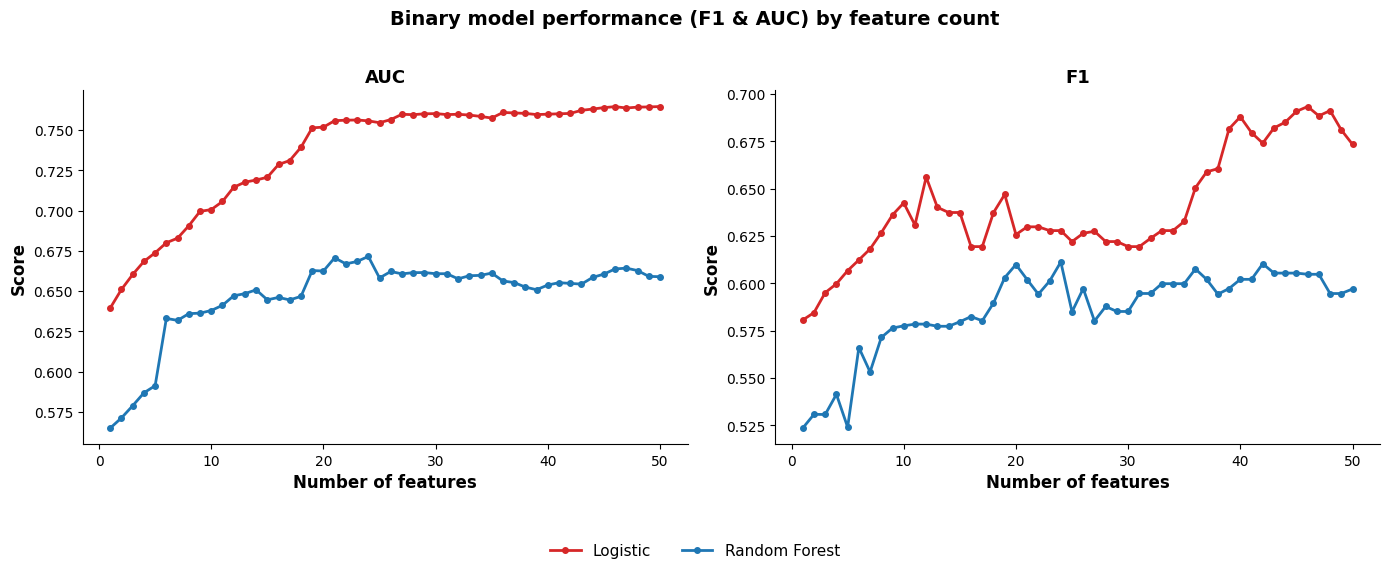

In [48]:
import matplotlib.pyplot as plt

# Prepare data for plotting
results_long = results_df.melt(
    id_vars=['k'],
    value_vars=['logit_f1', 'logit_auc', 'rf_f1', 'rf_auc'],
    var_name='metric_model',
    value_name='score'
)
results_long[['model', 'metric']] = results_long['metric_model'].str.split('_', expand=True)
results_long['model'] = results_long['model'].map({'logit': 'Logistic', 'rf': 'Random Forest'})
results_long['metric'] = results_long['metric'].str.upper()

# Create figure with two subplots (AUC and F1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic': '#d62728', 'Random Forest': '#1f77b4'}

for ax, metric in zip(axes, ['AUC', 'F1']):
    data_subset = results_long[results_long['metric'] == metric]

    for model in ['Logistic', 'Random Forest']:
        model_data = data_subset[data_subset['model'] == model]
        ax.plot(
            model_data['k'],
            model_data['score'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=model,
            color=colors[model]
        )

    ax.set_xlabel('Number of features', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.grid(False)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.legend(
    ['Logistic', 'Random Forest'],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=11,
    frameon=False
)

fig.suptitle('Binary model performance (F1 & AUC) by feature count', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

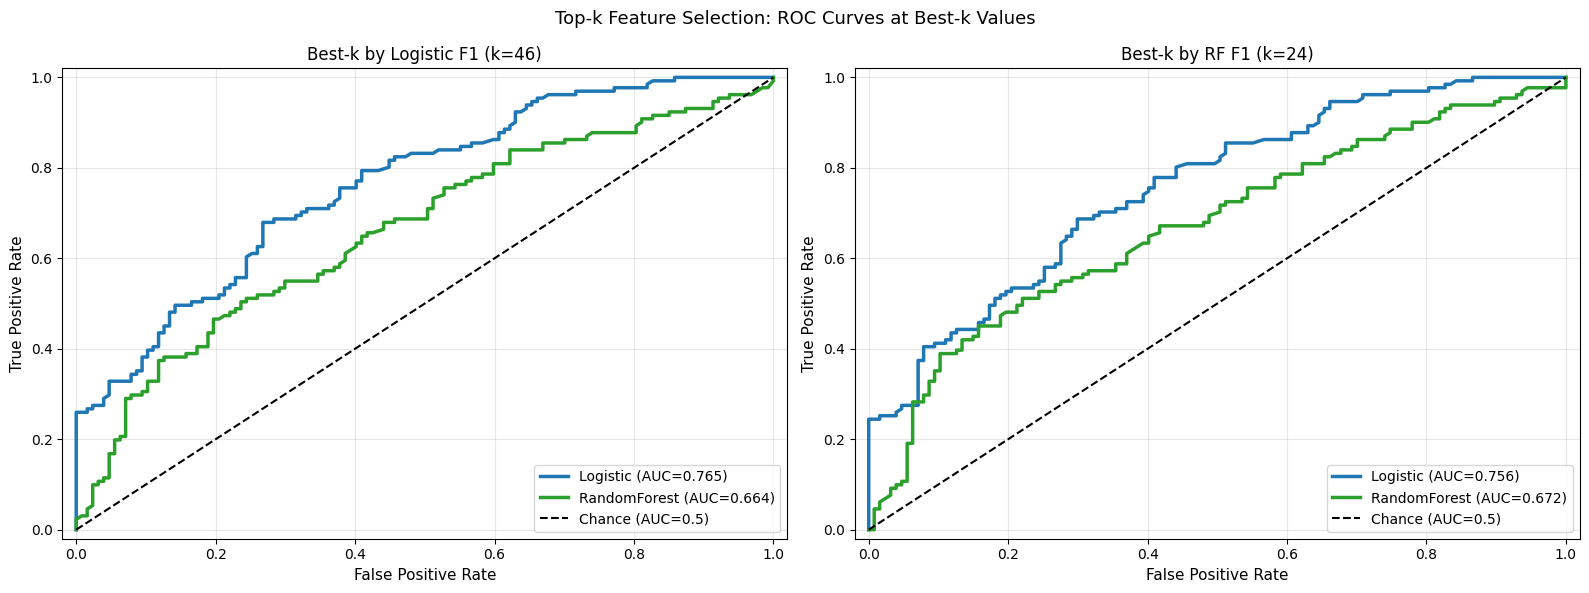

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import math

# Generate ROC curves at best-k values for each model/metric combo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Function to compute ROC at a given k
def compute_roc_at_k(k_val, model_name):
    features_k = selected_mrmr_features[:k_val]
    X_train_k  = X_outer_train[features_k]
    X_test_k   = X_outer_test[features_k]
    
    all_logit_probs_k, all_logit_obs_k = [], []
    all_rf_probs_k,    all_rf_obs_k    = [], []

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
    for train_idx, val_idx in skf.split(X_train_k, y_outer_train):
        X_tr  = X_train_k.iloc[train_idx]
        X_val = X_train_k.iloc[val_idx]
        y_tr  = y_outer_train.iloc[train_idx]
        y_val = y_outer_train.iloc[val_idx]

        logit = LogisticRegression(C=1e10, max_iter=1000, random_state=123, solver='lbfgs')
        logit.fit(X_tr, y_tr)
        y_prob_logit = logit.predict_proba(X_val)[:, list(logit.classes_).index(positive_label)]
        all_logit_probs_k.extend(y_prob_logit.tolist())
        all_logit_obs_k.extend(y_val.tolist())

        rf = RandomForestClassifier(
            n_estimators=500,
            max_features=max(1, math.floor(math.sqrt(k_val))),
            random_state=123
        )
        rf.fit(X_tr, y_tr)
        y_prob_rf = rf.predict_proba(X_val)[:, list(rf.classes_).index(positive_label)]
        all_rf_probs_k.extend(y_prob_rf.tolist())
        all_rf_obs_k.extend(y_val.tolist())

    obs_bin_logit = [1 if o == positive_label else 0 for o in all_logit_obs_k]
    obs_bin_rf    = [1 if o == positive_label else 0 for o in all_rf_obs_k]
    
    fpr_logit, tpr_logit, _ = roc_curve(obs_bin_logit, all_logit_probs_k)
    auc_logit = auc(fpr_logit, tpr_logit)
    
    fpr_rf, tpr_rf, _ = roc_curve(obs_bin_rf, all_rf_probs_k)
    auc_rf = auc(fpr_rf, tpr_rf)
    
    return (fpr_logit, tpr_logit, auc_logit, fpr_rf, tpr_rf, auc_rf)

# Best-k by Logistic F1
fpr_l, tpr_l, auc_l, fpr_r, tpr_r, auc_r = compute_roc_at_k(k_best_logit_f1, "Logistic F1")
axes[0].plot(fpr_l, tpr_l, color='tab:blue', lw=2.5, label=f'Logistic (AUC={auc_l:.3f})')
axes[0].plot(fpr_r, tpr_r, color='tab:green', lw=2.5, label=f'RandomForest (AUC={auc_r:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title(f'Best-k by Logistic F1 (k={k_best_logit_f1})', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# Best-k by RF F1
fpr_l, tpr_l, auc_l, fpr_r, tpr_r, auc_r = compute_roc_at_k(k_best_rf_f1, "RF F1")
axes[1].plot(fpr_l, tpr_l, color='tab:blue', lw=2.5, label=f'Logistic (AUC={auc_l:.3f})')
axes[1].plot(fpr_r, tpr_r, color='tab:green', lw=2.5, label=f'RandomForest (AUC={auc_r:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title(f'Best-k by RF F1 (k={k_best_rf_f1})', fontsize=12)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])

plt.suptitle('Top-k Feature Selection: ROC Curves at Best-k Values', fontsize=13)
plt.tight_layout()
plt.show()


# Best-k genes + metadata + WSI array

Fit a binary logistic regression model using:

- top-k selected genes (k = the feature count giving the highest CV F1 across both Logistic and RF in the top-k scan)
- patient metadata columns ('Split' removed)
- expanded WSI array values

Target: class_labels_MYC_V2_median (above_median vs below_median)

In [51]:

from pathlib import Path

import math
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

metadata_columns = [
    'gender',
    'age_diag',
    'grade',
    'cancer_history',
    'ajcc_path_tumor_pt',
    'ajcc_path_nodes_pn',
    'ajcc_clin_metastasis_cm',
    'ajcc_path_metastasis_pm',
    'ajcc_path_tumor_stage',
    'vital_status_12',
    'race_Asian',
    'race_Black or African American',
    'race_Hispanic or Latino',
    'race_White',
    'race_other',
    'VHL_mutation',
    'PBMR1_mutation',
    'TTN_mutation',
]

wsi_feature_dir = Path('/app/data/yash-m2m/Data/Features/WSI Features')

# k chosen as the feature count giving the best CV F1 across Logistic and RF
gene_k =  best_k_for_multimodal
gene_columns_topk = selected_mrmr_features[:gene_k]
print(f"Using k={gene_k} genes (source: {best_k_source})")
print("Gene columns:", gene_columns_topk)

required_columns = gene_columns_topk + metadata_columns + ['chosen_exam', target_col]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f'Missing expected columns: {missing_columns}')


def load_wsi_embedding(npz_name):
    npz_path = wsi_feature_dir / npz_name
    if not npz_path.exists():
        return None
    with np.load(npz_path) as data:
        embedding = np.ravel(data['arr_0']).astype(float)
    return embedding


model_df = df[required_columns].copy()
for col in gene_columns_topk:
    if col.startswith('Func_'):
        model_df[col] = model_df[col].map({'WT': 0, 'LOF': 1})

model_df['wsi_embedding'] = model_df['chosen_exam'].apply(load_wsi_embedding)
model_df = model_df.dropna(subset=[target_col, 'wsi_embedding']).copy()

embedding_lengths = model_df['wsi_embedding'].apply(len)
if embedding_lengths.nunique() != 1:
    raise ValueError(
        f'WSI embedding lengths are inconsistent: {embedding_lengths.value_counts().to_dict()}'
    )

wsi_array_df = pd.DataFrame(
    model_df['wsi_embedding'].tolist(),
    index=model_df.index,
).add_prefix('wsi_')

metadata_df = model_df[metadata_columns].apply(pd.to_numeric, errors='coerce')
gene_df = model_df[gene_columns_topk].apply(pd.to_numeric, errors='coerce')

raw_feature_df = pd.concat([gene_df, metadata_df, wsi_array_df], axis=1)
y_multimodal = model_df[target_col].astype(str)

positive_label = 'above_median'
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    raw_feature_df,
    y_multimodal,
    test_size=0.2,
    stratify=y_multimodal,
    random_state=123,
)

# Unregularized logistic with scaling + imputation, mirrors R pipeline
logit_multi = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C=1e10, max_iter=2000, random_state=123, solver='lbfgs')),
    ]
)

skf_multi = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_acc_scores_multi, cv_f1_scores_multi = [], []
all_probs_multi, all_obs_multi = [], []

for train_idx, val_idx in skf_multi.split(X_train_multi, y_train_multi):
    X_tr  = X_train_multi.iloc[train_idx]
    X_val = X_train_multi.iloc[val_idx]
    y_tr  = y_train_multi.iloc[train_idx]
    y_val = y_train_multi.iloc[val_idx]

    logit_multi.fit(X_tr, y_tr)
    y_pred_multi = logit_multi.predict(X_val)
    y_prob_multi = logit_multi.predict_proba(X_val)[
        :, list(logit_multi.named_steps['model'].classes_).index(positive_label)
    ]

    cv_acc_scores_multi.append(accuracy_score(y_val, y_pred_multi))
    cv_f1_scores_multi.append(f1_score(y_val, y_pred_multi, pos_label=positive_label, zero_division=0))
    all_probs_multi.extend(y_prob_multi.tolist())
    all_obs_multi.extend(y_val.tolist())

# Pooled OOF AUC — mirrors pROC roc() on accumulated fold predictions
cv_auc_pooled_multi = roc_auc_score(
    [1 if o == positive_label else 0 for o in all_obs_multi], all_probs_multi
)

logit_multi.fit(X_train_multi, y_train_multi)
y_test_pred_multi = logit_multi.predict(X_test_multi)
y_test_prob_multi = logit_multi.predict_proba(X_test_multi)[
    :, list(logit_multi.named_steps['model'].classes_).index(positive_label)
]

missing_wsi_files = int(model_df['wsi_embedding'].isna().sum())

topk_multimodal_results = pd.Series(
    {
        'target':               target_col,
        'gene_k':               gene_k,
        'gene_k_source':        best_k_source,
        'n_samples':            len(raw_feature_df),
        'n_features_total':     raw_feature_df.shape[1],
        'n_gene_features':      len(gene_columns_topk),
        'n_metadata_features':  len(metadata_columns),
        'n_wsi_features':       wsi_array_df.shape[1],
        'cv_accuracy':          np.mean(cv_acc_scores_multi),
        'cv_f1':                np.mean(cv_f1_scores_multi),
        'cv_auc_pooled_oof':    cv_auc_pooled_multi,
        'test_accuracy':        accuracy_score(y_test_multi, y_test_pred_multi),
        'test_f1':              f1_score(y_test_multi, y_test_pred_multi, pos_label=positive_label, zero_division=0),
        'test_auc':             roc_auc_score((y_test_multi == positive_label).astype(int), y_test_prob_multi),
    }
)

print(f'Gene columns (k={gene_k}):', gene_columns_topk)
print('WSI embedding length:', wsi_array_df.shape[1])
print('Missing WSI files:', missing_wsi_files)
print('\nBinary multimodal logistic results:')
topk_multimodal_results


Using k=46 genes (source: Logistic F1 (k=46, F1=0.693))
Gene columns: ['TMB_Count', 'Func_RALGAPA1', 'Func_OR2T35', 'Func_MEGF6', 'Func_ARID1A', 'Func_PBRM1', 'Func_MSLNL', 'Func_FOXD4L4', 'Func_ATM', 'Func_MAGEC1', 'Func_YLPM1', 'Func_PABPC1', 'Func_TRIP12', 'Func_NUP37', 'Func_PLEKHA2', 'Func_GATA2', 'Func_ZSCAN16', 'Func_ATG7', 'Func_SYT15', 'Func_DPPA2', 'Func_DNMT3A', 'Func_IPP', 'Func_FAM209A', 'Func_CACYBP', 'Func_DHX37', 'Func_MAK16', 'Func_CASQ1', 'Func_PTPN18', 'Func_EME2', 'Func_CASP5', 'Func_HOXC8', 'Func_KLK13', 'Func_PRSS16', 'Func_SAMD5', 'Func_TMEM54', 'Func_ANKRD12', 'Func_ANKRD36', 'Func_HLA-DRB1', 'Func_LCN1', 'Func_PLD3', 'Func_ST8SIA4', 'Func_SUCLG1', 'Func_L1TD1', 'Func_ZDHHC1', 'Func_GPRC6A', 'Func_MCPH1']
Gene columns (k=46): ['TMB_Count', 'Func_RALGAPA1', 'Func_OR2T35', 'Func_MEGF6', 'Func_ARID1A', 'Func_PBRM1', 'Func_MSLNL', 'Func_FOXD4L4', 'Func_ATM', 'Func_MAGEC1', 'Func_YLPM1', 'Func_PABPC1', 'Func_TRIP12', 'Func_NUP37', 'Func_PLEKHA2', 'Func_GATA2', 'Func_

target                   class_labels_MYC_V2_median
gene_k                                           46
gene_k_source          Logistic F1 (k=46, F1=0.693)
n_samples                                       323
n_features_total                               1088
n_gene_features                                  46
n_metadata_features                              18
n_wsi_features                                 1024
cv_accuracy                                0.577538
cv_f1                                      0.564941
cv_auc_pooled_oof                            0.5953
test_accuracy                              0.492308
test_f1                                    0.507463
test_auc                                   0.493371
dtype: object

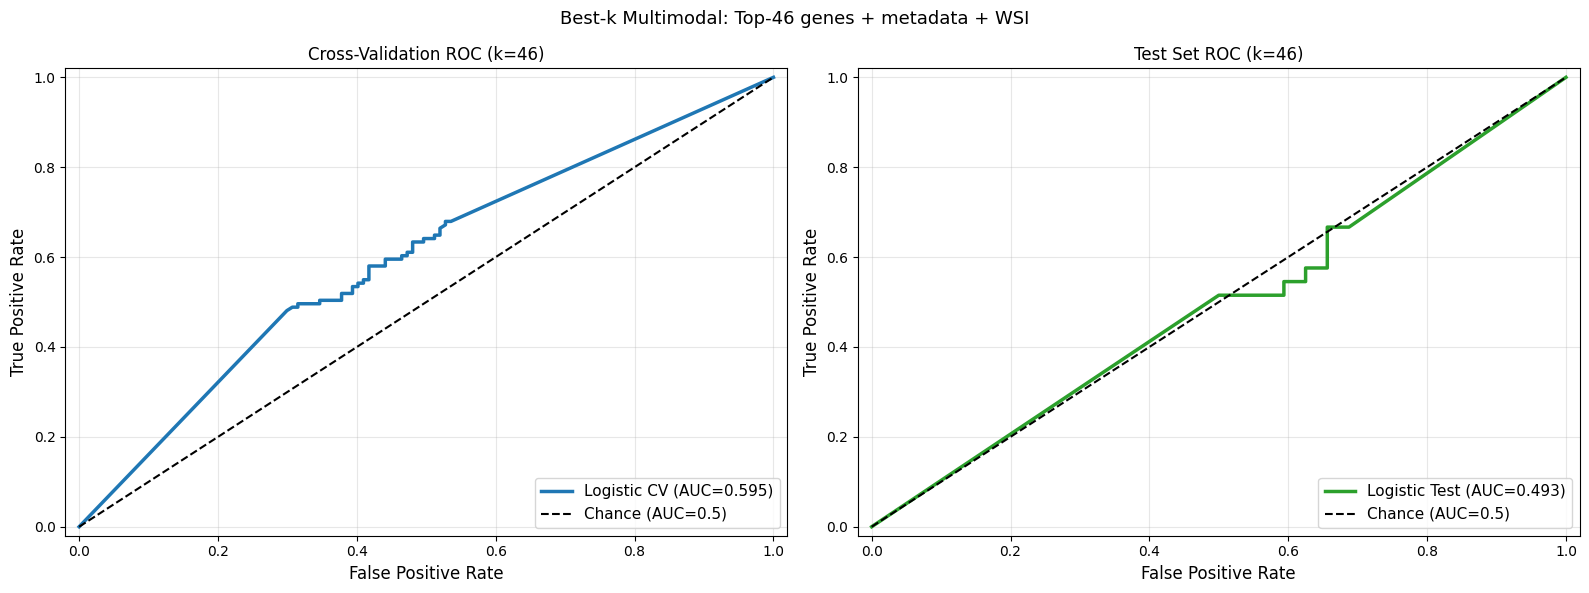

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for best-k multimodal model (CV pooled OOF + test set)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CV ROC (pooled OOF)
fpr_cv, tpr_cv, _ = roc_curve(
    [1 if o == positive_label else 0 for o in all_obs_multi],
    all_probs_multi
)
auc_cv = auc(fpr_cv, tpr_cv)
axes[0].plot(fpr_cv, tpr_cv, color='tab:blue', lw=2.5, label=f'Logistic CV (AUC={auc_cv:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title(f'Cross-Validation ROC (k={gene_k})', fontsize=12)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# Test ROC
fpr_test, tpr_test, _ = roc_curve(
    (y_test_multi == positive_label).astype(int),
    y_test_prob_multi
)
auc_test = auc(fpr_test, tpr_test)
axes[1].plot(fpr_test, tpr_test, color='tab:green', lw=2.5, label=f'Logistic Test (AUC={auc_test:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title(f'Test Set ROC (k={gene_k})', fontsize=12)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])


plt.suptitle(f'Best-k Multimodal: Top-{gene_k} genes + metadata + WSI', fontsize=13)
plt.tight_layout()
plt.show()